# Modelado: Modelo SOTA de referencia

Antes de evaluar el desempeño del modelo propuesto, es indispensable construir un conjunto de modelos de referencia (*baselines*) que representen el estado del arte visto durante el curso, abarcando desde modelos clásicos de aprendizaje automático hasta arquitecturas más avanzadas. Cada modelo se entrena, se ajusta mediante búsqueda de hiperparámetros y se evalúa bajo el mismo esquema de partición y las mismas métricas que se usarán para el modelo novedoso.

---

In [13]:
# Librerias
## Librerías estándar de Python
import pickle
import time

# Cómputo numérico y tabular
import numpy as np
import pandas as pd

## Visualización
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay
)

RANDOM_STATE = 42

In [5]:
with open("datos_modelado.pkl", "rb") as f:
    datos = pickle.load(f)

X_train = datos["X_train"]
X_test = datos["X_test"]
y_train = datos["y_train"]
y_test = datos["y_test"]

In [7]:
print(" RESUMEN DE LAS PARTICIONES")
print("═" * 60)
print(f"  Observaciones de entrenamiento : {X_train.shape[0]}")
print(f"  Observaciones de prueba        : {X_test.shape[0]}")
print(f"  Variables predictoras          : {X_train.shape[1]}")
print("\n  Distribución de clases (train):")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + " %")
print("\n  Distribución de clases (test):")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + " %")

 RESUMEN DE LAS PARTICIONES
════════════════════════════════════════════════════════════
  Observaciones de entrenamiento : 671
  Observaciones de prueba        : 168
  Variables predictoras          : 23

  Distribución de clases (train):
Grade
0    57.97 %
1    42.03 %
Name: proportion, dtype: object

  Distribución de clases (test):
Grade
0    58.33 %
1    41.67 %
Name: proportion, dtype: object


## 2.1 Regresión Logística

La regresión logística es uno de los modelos más utilizados en investigación clínica y genómica para problemas de clasificación binaria, precisamente el tipo de problema que se aborda en este proyecto (`Grade`: LGG = 0 vs. GBM = 1).
Se selecciona como *baseline* por las siguientes razones:

- **Interpretabilidad**: Sus coeficientes se traducen directamente en *odds ratios*, lo que permite cuantificar la contribución de cada mutación genética y de la edad al riesgo de un grado tumoral más agresivo — un estándar de facto en la literatura de oncología genómica.
- **Simplicidad y bajo costo computacional**: Al ser un modelo lineal, su entrenamiento e inferencia son extremadamente rápidos, lo que la convierte en una referencia natural de eficiencia frente a modelos más complejos.
- **Robustez con pocas muestras y variables**: Dado el número de predictores, es un modelo con bajo riesgo de sobreajuste, útil como cota inferior de referencia.
- **Estándar en la literatura**: Es el modelo base reportado en la mayoría de estudios de clasificación de grado tumoral en gliomas, lo que facilita la comparación con resultados externos.

**Formulación matemática**

Dado un vector de características $\mathbf{x} \in \mathbb{R}^{p}$, el modelo estima la probabilidad de que un paciente pertenezca a la clase GBM ($y=1$) mediante la función logística (sigmoide) aplicada a una combinación lineal de los predictores:

$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^{\top}\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^{\top}\mathbf{x} + b)}}
\tag{2.1}
$$

donde $\mathbf{w} \in \mathbb{R}^{p}$ es el vector de pesos y $b$ el término de sesgo (*intercept*). Los parámetros $(\mathbf{w}, b)$ se estiman minimizando la función de pérdida de entropía cruzada binaria (*log-loss*), con un término de regularización $L_2$ (o $L_1$, según el hiperparámetro `penalty`) que controla la complejidad del modelo:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\Big] + \frac{1}{C}\,\lVert \mathbf{w} \rVert_k
\tag{2.2}
$$

con $\hat{p}_i = P(y=1 \mid \mathbf{x}_i)$, $n$ el número de observaciones de entrenamiento, $k \in \{1,2\}$ el tipo de norma de regularización, y $C > 0$ el inverso de la fuerza de regularización (a menor $C$, mayor regularización).

**Hiperparámetros ajustables (Grid Search, validación cruzada $k=5$)**

| Hiperparámetro | Descripción | Rango explorado |
|---|---|---|
| `C` | Inverso de la fuerza de regularización | `np.logspace(-3, 3, 13)` → $[0.001,\ 1000]$ |
| `penalty` | Tipo de regularización | `{'l1', 'l2'}` |
| `solver` | Algoritmo de optimización (compatible con `l1` y `l2`) | `'liblinear'` |
| `class_weight` | Balanceo de clases | `{None, 'balanced'}` |

### Preprocesamiento

Se utiliza el **conjunto completo de variables disponibles**: la variable clínica numérica (`Age_at_diagnosis`), las variables clínicas categóricas (`Gender`, `Race`) y las **20 variables genéticas** de mutación. La estrategia de transformación depende del tipo de variable:

- **Numéricas** → estandarización (`StandardScaler`), ya que la regresión logística es sensible a la escala de las variables al estar regularizada.
- **Categóricas** (`Gender`, `Race`) → codificación *one-hot* (`OneHotEncoder`), ignorando categorías no vistas en entrenamiento.
- **Genéticas** → se dejan sin transformar (`passthrough`), pues ya se encuentran codificadas como indicadores binarios (0/1).

In [9]:
variables_numericas = [
    "Age_at_diagnosis"
]

variables_categoricas = [
    "Gender",
    "Race"
]

variables_geneticas = [
    "IDH1",
    "TP53",
    "ATRX",
    "PTEN",
    "EGFR",
    "CIC",
    "MUC16",
    "PIK3CA",
    "NF1",
    "PIK3R1",
    "FUBP1",
    "RB1",
    "NOTCH1",
    "BCOR",
    "CSMD3",
    "SMARCA4",
    "GRIN2A",
    "IDH2",
    "FAT4",
    "PDGFRA"
]

preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), variables_numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas),
        ("geneticas", "passthrough", variables_geneticas)
    ]
)

total_variables = len(variables_numericas) + len(variables_categoricas) + len(variables_geneticas)
print(f"Total de variables utilizadas: {total_variables} "
      f"({len(variables_numericas)} numérica, {len(variables_categoricas)} categóricas, "
      f"{len(variables_geneticas)} genéticas)")

Total de variables utilizadas: 23 (1 numérica, 2 categóricas, 20 genéticas)


### Hiperparámetros (Grid Search)

Se define el `Pipeline` y se optimiza mediante `GridSearchCV` con validación cruzada estratificada de 5 particiones, usando **AUC-ROC** como métrica de selección por ser robusta ante un eventual desbalance de clases. El rango de búsqueda para cada hiperparámetro es el indicado en la tabla anteriormente mostrada.

In [ ]:
modelo_logistico = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("regresion_logistica", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    "regresion_logistica__C": np.logspace(-3, 3, 13),
    "regresion_logistica__penalty": ["l1", "l2"],
    "regresion_logistica__solver": ["liblinear"],
    "regresion_logistica__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_lr = GridSearchCV(
    estimator=modelo_logistico,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

t0 = time.perf_counter()
grid_search_lr.fit(X_train, y_train)
train_time_lr = time.perf_counter() - t0

modelo_logistico = grid_search_lr.best_estimator_

print(" MEJOR CONFIGURACIÓN — REGRESIÓN LOGÍSTICA")
print("═" * 60)
for k, v in grid_search_lr.best_params_.items():
    print(f"  {k.replace('regresion_logistica__', ''):>15}: {v}")
print(f"\n  AUC-ROC promedio (CV, 5-fold): {grid_search_lr.best_score_:.4f}")
print(f"  Tiempo total de búsqueda + entrenamiento: {train_time_lr:.3f} s")

════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN — REGRESIÓN LOGÍSTICA
════════════════════════════════════════════════════════════
                C: 0.31622776601683794
     class_weight: None
          penalty: l1
           solver: liblinear

  AUC-ROC promedio (CV, 5-fold): 0.9165
  Tiempo total de búsqueda + entrenamiento: 13.995 s


### Evaluación - `X_test`

Con el mejor modelo encontrado, se calculan las métricas estándar de clasificación binaria sobre el conjunto de prueba, junto con el tiempo de inferencia, dado que ambas dimensiones —error/precisión y tiempo de cómputo— son necesarias para la comparación final con el modelo propuesto.

In [15]:
t0 = time.perf_counter()
y_pred = modelo_logistico.predict(X_test)
y_proba = modelo_logistico.predict_proba(X_test)[:, 1]
inference_time_lr = time.perf_counter() - t0

metrics_lr = {
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_proba),
    "Tiempo entrenamiento (s)": train_time_lr,
    "Tiempo inferencia (s)": inference_time_lr,
}

df_metrics_lr = pd.DataFrame([metrics_lr]).set_index("Modelo")
display(df_metrics_lr.style.background_gradient(
            cmap="Blues", subset=["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"])
        .format(precision=4)
        .set_caption("Resumen de desempeño en test — Baseline: Regresión Logística"))

print("\nReporte de clasificación detallado:\n")
print(classification_report(y_test, y_pred, target_names=["LGG (0)", "GBM (1)"]))

,Accuracy,Precision,Recall,F1-score,AUC-ROC,Tiempo entrenamiento (s),Tiempo inferencia (s)
Modelo,,,,,,,
Regresión Logística,0.8690,0.7927,0.9286,0.8553,0.9149,13.9955,0.0423



Reporte de clasificación detallado:

              precision    recall  f1-score   support

     LGG (0)       0.94      0.83      0.88        98
     GBM (1)       0.79      0.93      0.86        70

    accuracy                           0.87       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.87      0.87       168



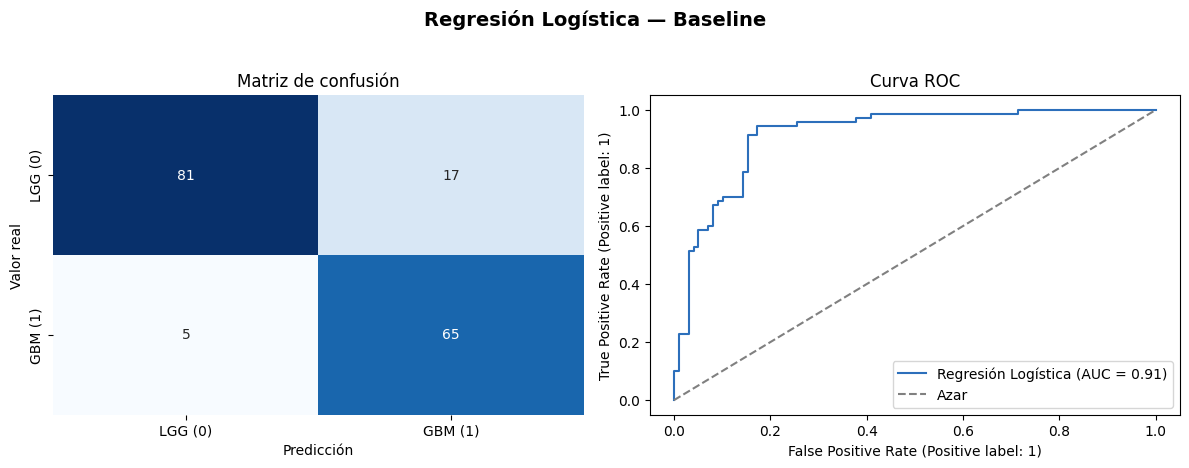

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["LGG (0)", "GBM (1)"], yticklabels=["LGG (0)", "GBM (1)"], ax=axes[0])
axes[0].set_title("Matriz de confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

# Curva ROC 
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#2c6fbb", name="Regresión Logística")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

fig.suptitle("Regresión Logística — Baseline", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Validación cruzada

Adicionalmente, se evalúa la estabilidad del modelo (con los hiperparámetros ya seleccionados) mediante validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento, reportando la media y la desviación estándar de cada métrica.

In [17]:
resultados_cv = cross_validate(
    clone(modelo_logistico),
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

metricas_cv = pd.DataFrame({
    "Media": {
        "Accuracy": resultados_cv["test_accuracy"].mean(),
        "Precision": resultados_cv["test_precision"].mean(),
        "Recall": resultados_cv["test_recall"].mean(),
        "F1-score": resultados_cv["test_f1"].mean(),
        "AUC-ROC": resultados_cv["test_roc_auc"].mean(),
    },
    "Desv. estándar": {
        "Accuracy": resultados_cv["test_accuracy"].std(),
        "Precision": resultados_cv["test_precision"].std(),
        "Recall": resultados_cv["test_recall"].std(),
        "F1-score": resultados_cv["test_f1"].std(),
        "AUC-ROC": resultados_cv["test_roc_auc"].std(),
    }
})

display(metricas_cv.style.background_gradient(cmap="Blues", subset=["Media"])
        .format(precision=4)
        .set_caption("Validación cruzada (5-fold) sobre entrenamiento — Regresión Logística"))

,Media,Desv. estándar
Accuracy,0.8644,0.0131
Precision,0.8013,0.0314
Recall,0.9042,0.0266
F1-score,0.8487,0.0114
AUC-ROC,0.9165,0.0164


### Interpretabilidad del modelo

Una de las principales ventajas de la regresión logística frente a modelos más complejos es que su resultado es directamente interpretable, ya que cada variable de entrada tiene asociado un coeficiente $w_i$ cuyo signo y magnitud indican cómo influye esa variable en la probabilidad estimada de que el paciente pertenezca a la clase GBM ($y=1$).

- Un coeficiente **positivo** aumenta el *log-odds* de GBM (la variable empuja la predicción hacia GBM).
- Un coeficiente **negativo** lo disminuye (la variable empuja la predicción hacia LGG).
- Su exponencial, $e^{w_i}$, corresponde al ***odds ratio***: indica por cuánto se multiplican las probabilidades (*odds*) de GBM por cada unidad de aumento en esa variable (o, en variables binarias, al pasar de 0 a 1). Un *odds ratio* de 2.0 implica que duplica las chances de GBM; uno de 0.5, que las reduce a la mitad.

Como las variables categóricas (`Gender`, `Race`) fueron transformadas mediante *one-hot encoding*, primero se reconstruyen sus nombres reales a partir del `ColumnTransformer` ya ajustado, de modo que cada coeficiente pueda asociarse correctamente a su variable de origen. Luego se ordenan las variables por la magnitud absoluta de su coeficiente, para identificar cuáles tienen mayor peso en la predicción del modelo — clínica y genéticamente relevante para validar si el *baseline* está capturando señales consistentes con la literatura (p. ej., mutaciones de IDH1 asociadas a LGG).

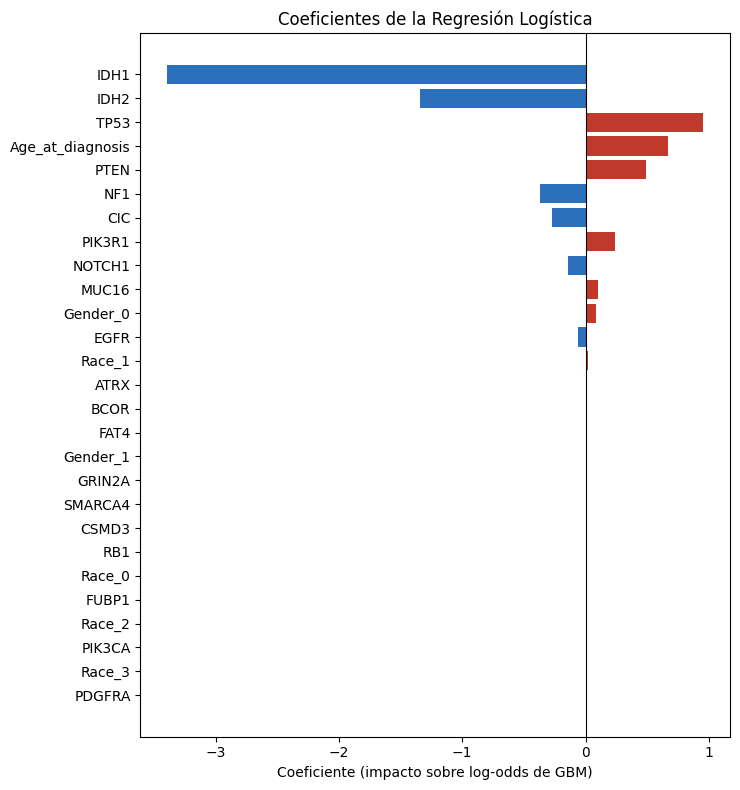

,Variable,Coeficiente,Odds Ratio
0,IDH1,-3.392,0.034
1,IDH2,-1.343,0.261
2,TP53,0.954,2.595
3,Age_at_diagnosis,0.667,1.949
4,PTEN,0.491,1.635
5,NF1,-0.373,0.689
6,CIC,-0.273,0.761
7,PIK3R1,0.236,1.266
8,NOTCH1,-0.140,0.870
9,MUC16,0.102,1.107


In [18]:
preproc_fit = modelo_logistico.named_steps["preprocesamiento"]
nombres_categoricas = list(
    preproc_fit.named_transformers_["categoricas"].get_feature_names_out(variables_categoricas)
)
nombres_variables = variables_numericas + nombres_categoricas + variables_geneticas

coef = modelo_logistico.named_steps["regresion_logistica"].coef_.ravel()
odds_ratio = np.exp(coef)

df_coef = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coef,
    "Odds Ratio": odds_ratio
}).sort_values("Coeficiente", key=np.abs, ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 8))
colors = ["#c0392b" if c > 0 else "#2c6fbb" for c in df_coef["Coeficiente"]]
ax.barh(df_coef["Variable"], df_coef["Coeficiente"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes de la Regresión Logística")
ax.set_xlabel("Coeficiente (impacto sobre log-odds de GBM)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(df_coef.head(10).style.background_gradient(cmap="RdBu_r", subset=["Coeficiente"])
        .format({"Coeficiente": "{:.3f}", "Odds Ratio": "{:.3f}"})
        .set_caption("Top 10 variables con mayor impacto — Regresión Logística"))

### Síntesis

> Las métricas obtenidas en `df_metrics_lr` (Accuracy, F1-score, AUC-ROC, tiempo de entrenamiento e inferencia) y en `metricas_cv` (robustez vía validación cruzada) quedan registradas como referencia de la **Regresión Logística** con el conjunto completo de variables disponibles. Estos resultados se incorporarán a la tabla comparativa consolidada al final de la sección de *baselines*, junto con los demás modelos clásicos y profundos vistos en el curso, para contrastarlos posteriormente contra el modelo propuesto. En caso de que el modelo novedoso no logre superar a este *baseline* en alguna de las dos dimensiones evaluadas (error/precisión o tiempo de cómputo), dicho resultado se reportará y discutirá honestamente en las secciones de Resultados y Conclusiones.